<a href="https://colab.research.google.com/github/edjuaro/MentorMatch/blob/main/Advisor_Matching_No_Widgets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell retrieves academic paper data (titles, abstracts, years, and venues) for predefined authors from the Semantic Scholar API and saves them into separate `.txt` files. This process creates the source material for later semantic similarity calculations.

In [6]:
import requests
import time

# Mapping filenames to your Semantic Scholar Author IDs
PROFILES = {
    "Edwin_F_Juarez": "8681229",
    "Edwin_Rosales": "2182822831",
    "E_Juarez": "2250643075"
}

def get_paper_data(author_id):
    # Only request the core metadata we want: title and abstract
    url = f"https://api.semanticscholar.org/graph/v1/author/{author_id}/papers?fields=title,abstract,year,venue"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json().get('data', [])
    return []

# Process each profile into its own text file
for profile_name, author_id in PROFILES.items():
    filename = f"{profile_name}.txt"
    print(f"Gathering abstracts for profile: {profile_name}...")

    papers = get_paper_data(author_id)
    if not papers:
        print(f"  No data found or API error for {profile_name}.")
        continue

    print(f"  Writing {len(papers)} papers to {filename}...")

    with open(filename, 'w', encoding='utf-8') as f:
        f.write(f"==================================================\n")
        f.write(f"PUBLICATIONS ABSTRACTS FOR: {profile_name.replace('_', ' ')}\n")
        f.write(f"==================================================\n\n")

        for i, paper in enumerate(papers):
            title = paper.get('title', 'Untitled')
            year = paper.get('year', 'N/A')
            venue = paper.get('venue', 'Unknown Venue')
            abstract = paper.get('abstract', 'No abstract available in the index.')

            f.write(f"[{i+1}] TITLE: {title}\n")
            f.write(f"    YEAR: {year} | VENUE: {venue}\n")
            f.write("-" * 50 + "\n")
            f.write(f"{abstract}\n")
            f.write("\n" + "="*60 + "\n\n")

    # Tiny sleep just to respect the endpoint pacing
    time.sleep(0.2)

print("\n--- ALL COMPLETED SUCCESSFULLY ---")
print("Check your left-side files panel for the clean .txt outputs.")

Gathering abstracts for profile: Edwin_F_Juarez...
  Writing 19 papers to Edwin_F_Juarez.txt...
Gathering abstracts for profile: Edwin_Rosales...
  Writing 4 papers to Edwin_Rosales.txt...
Gathering abstracts for profile: E_Juarez...
  Writing 9 papers to E_Juarez.txt...

--- ALL COMPLETED SUCCESSFULLY ---
Check your left-side files panel for the clean .txt outputs.


This cell first calculates the character length of the previously generated `.txt` files. It then creates a new placeholder text file, `Lorena_Ipanema.txt`, whose content length matches the maximum length found among the existing academic `.txt` files. This ensures a consistent text length for comparative analysis.

In [7]:
import os

# Define an English equivalent placeholder text.
# This approach avoids external dependencies and uses a more natural English flow.
lorem_base_text = (
    "This is an English equivalent of Lorem Ipsum, often used as placeholder text "
    "in publishing and graphic design. It helps designers and developers focus "
    "on the layout and visual presentation without being distracted by meaningful "
    "content. It also allows for a clear distinction between the content and "
    "the design elements. All of this content is generated for testing purposes, "
    "and it is not intended to convey any specific message."
)

# List of existing files to calculate length from
file_names = [
    "Edwin_F_Juarez.txt",
    "Edwin_Rosales.txt",
    "E_Juarez.txt"
]

file_lengths = []

# Calculate the character length of each specified file
print("Calculating lengths from existing files...")
for filename in file_names:
    try:
        # Ensure the file exists in the current directory, if not, check /content/
        if not os.path.exists(filename):
            if os.path.exists(os.path.join('/content', filename)):
                filename = os.path.join('/content', filename)
            else:
                print(f"  Warning: File not found: {filename}. It will not be included in the length calculation.")
                continue

        with open(filename, 'r', encoding='utf-8') as f:
            content = f.read()
            file_lengths.append(len(content))
        print(f"  Length of {filename}: {len(content)} characters")
    except Exception as e:
        print(f"  Error reading {filename}: {e}. It will not be included in the length calculation.")

target_length = 0
if file_lengths:
    target_length = max(file_lengths) # Use the maximum length
    print(f"\nTarget character length for the new file (based on largest existing file): {target_length}")
else:
    print("\nNo specified files were found to calculate a target length. Using a default length of 1000 characters for placeholder text.")
    target_length = 1000 # Default if no files are found

# Generate placeholder text by repeating the base text
lorem_text = ""
while len(lorem_text) < target_length:
    lorem_text += lorem_base_text + " "

# Truncate the placeholder text to the calculated target length
lorem_text_final = lorem_text[:int(target_length)].strip()

# Define the output filename
output_filename = "Lorena_Ipanema.txt"

# Write the placeholder text to the new file
with open(output_filename, 'w', encoding='utf-8') as f:
    f.write(lorem_text_final)

print(f"\nSuccessfully generated '{output_filename}' with approximately {len(lorem_text_final)} characters (target: {target_length}).")
print("You can check your left-side files panel for the new file.")

Calculating lengths from existing files...
  Length of Edwin_F_Juarez.txt: 31338 characters
  Length of Edwin_Rosales.txt: 4586 characters
  Length of E_Juarez.txt: 12090 characters

Target character length for the new file (based on largest existing file): 31338

Successfully generated 'Lorena_Ipanema.txt' with approximately 31338 characters (target: 31338).
You can check your left-side files panel for the new file.


This cell defines two sample text snippets, `sample1` and `sample2` similating writing samples from the student (e.g., a research statement), which will be used as reference points to compute semantic similarity against the content of the `.txt` files generated from the academic profiles. These samples allow us to assess how closely the professors' work aligns with the applicant's specific research interests.

In [8]:
sample1 = """NMF Clustering: Accessible NMF-based Clustering Utilizing GPU Acceleration
Ted Liefeld 1, Edwin Huang 1, Alexander T Wenzel 1, Kenneth Yoshimoto 2, Ashwyn K Sharma 3, Jason K Sicklick 4, Jill P Mesirov 1 3, Michael Reich 1
Affiliations Expand
PMID: 38390437 PMCID: PMC10883375 DOI: 10.26502/jbsb.5107072
Abstract
Non-negative Matrix Factorization (NMF) is an algorithm that can reduce high dimensional datasets of tens of thousands of genes to a handful of metagenes which are biologically easier to interpret. Application of NMF on gene expression data has been limited by its computationally intensive nature, which hinders its use on large datasets such as single-cell RNA sequencing (scRNA-seq) count matrices. We have implemented NMF based clustering to run on high performance GPU compute nodes using CuPy, a GPU backed python library, and the Message Passing Interface (MPI). This reduces the computation time by up to three orders of magnitude and makes the NMF Clustering analysis of large RNA-Seq and scRNA-seq datasets practical. We have made the method freely available through the GenePattern gateway, which provides free public access to hundreds of tools for the analysis and visualization of multiple 'omic data types. Its web-based interface gives easy access to these tools and allows the creation of multi-step analysis pipelines on high performance computing (HPC) clusters that enable reproducible in silico research for non-programmers.

Keywords: Gene; NMF; scRNA-seq."""

sample2 = """Single-cell characterization of step-wise acquisition of carboplatin resistance in ovarian cancer
Alexander T Wenzel # 1 2, Devora Champa # 3 4, Hrishi Venkatesh 5 6, Si Sun 3 7, Cheng-Yu Tsai 3 8, Jill P Mesirov 2 3, Jack D Bui 9, Stephen B Howell 10 11, Olivier Harismendy 12 13
Affiliations Expand
PMID: 35715421 PMCID: PMC9206019 DOI: 10.1038/s41540-022-00230-z
Abstract
The molecular underpinnings of acquired resistance to carboplatin are poorly understood and often inconsistent between in vitro modeling studies. After sequential treatment cycles, multiple isogenic clones reached similar levels of resistance, but significant transcriptional heterogeneity. Gene-expression based virtual synchronization of 26,772 single cells from 2 treatment steps and 4 resistant clones was used to evaluate the activity of Hallmark gene sets in proliferative (P) and quiescent (Q) phases. Two behaviors were associated with resistance: (1) broad repression in the P phase observed in all clones in early resistant steps and (2) prevalent induction in Q phase observed in the late treatment step of one clone. Furthermore, the induction of IFNα response in P phase or Wnt-signaling in Q phase were observed in distinct resistant clones. These observations suggest a model of resistance hysteresis, where functional alterations of the P and Q phase states affect the dynamics of the successive transitions between drug exposure and recovery, and prompts for a precise monitoring of single-cell states to develop more effective schedules for, or combination of, chemotherapy treatments."""

This cell performs the core semantic similarity calculation. It first ensures the `sentence-transformers` library is installed, then loads a pre-trained `all-MiniLM-L6-v2` model. It converts `sample1`, `sample2`, and the content of all `.txt` files into numerical embeddings (vector representations). Finally, it calculates and displays the cosine similarity scores between each sample and each file, quantifying how semantically similar they are.

<!-- An explanation of Vector Space Models, Cosine Similarity, and Sentence Transformers is also provided. -->

In [9]:
import os
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch # To handle tensors

# Install sentence_transformers if not already installed
try:
    from sentence_transformers import SentenceTransformer, util
except ImportError:
    !pip install -U sentence-transformers
    from sentence_transformers import SentenceTransformer, util

# Ensure sample1 and sample2 are defined if this cell is run independently
# (assuming they are in the user's namespace from a previous cell, but redefining for robustness)
if 'sample1' not in locals() and 'sample1' not in globals():
    sample1 = """NMF Clustering: Accessible NMF-based Clustering Utilizing GPU Acceleration
Ted Liefeld 1, Edwin Huang 1, Alexander T Wenzel 1, Kenneth Yoshimoto 2, Ashwyn K Sharma 3, Jason K Sicklick 4, Jill P Mesirov 1 3, Michael Reich 1
Affiliations Expand
PMID: 38390437 PMCID: PMC10883375 DOI: 10.26502/jbsb.5107072
Abstract
Non-negative Matrix Factorization (NMF) is an algorithm that can reduce high dimensional datasets of tens of thousands of genes to a handful of metagenes which are biologically easier to interpret. Application of NMF on gene expression data has been limited by its computationally intensive nature, which hinders its use on large datasets such as single-cell RNA sequencing (scRNA-seq) count matrices. We have implemented NMF based clustering to run on high performance GPU compute nodes using CuPy, a GPU backed python library, and the Message Passing Interface (MPI). This reduces the computation time by up to three orders of magnitude and makes the NMF Clustering analysis of large RNA-Seq and scRNA-seq datasets practical. We have made the method freely available through the GenePattern gateway, which provides free public access to hundreds of tools for the analysis and visualization of multiple 'omic data types. Its web-based interface gives easy access to these tools and allows the creation of multi-step analysis pipelines on high performance computing (HPC) clusters that enable reproducible in silico research for non-programmers.

Keywords: Gene; NMF; scRNA-seq."""
if 'sample2' not in locals() and 'sample2' not in globals():
    sample2 = """Single-cell characterization of step-wise acquisition of carboplatin resistance in ovarian cancer
Alexander T Wenzel # 1 2, Devora Champa # 3 4, Hrishi Venkatesh 5 6, Si Sun 3 7, Cheng-Yu Tsai 3 8, Jill P Mesirov 2 3, Jack D Bui 9, Stephen B Howell 10 11, Olivier Harismendy 12 13
Affiliations Expand
PMID: 35715421 PMCID: PMC9206019 DOI: 10.1038/s41540-022-00230-z
Abstract
The molecular underpinnings of acquired resistance to carboplatin are poorly understood and often inconsistent between in vitro modeling studies. After sequential treatment cycles, multiple isogenic clones reached similar levels of resistance, but significant transcriptional heterogeneity. Gene-expression based virtual synchronization of 26,772 single cells from 2 treatment steps and 4 resistant clones was used to evaluate the activity of Hallmark gene sets in proliferative (P) and quiescent (Q) phases. Two behaviors were associated with resistance: (1) broad repression in the P phase observed in all clones in early resistant steps and (2) prevalent induction in Q phase observed in the late treatment step of one clone. Furthermore, the induction of IFN̑ response in P phase or Wnt-signaling in Q phase were observed in distinct resistant clones. These observations suggest a model of resistance hysteresis, where functional alterations of the P and Q phase states affect the dynamics of the successive transitions between drug exposure and recovery, and prompts for a precise monitoring of single-cell states to develop more effective schedules for, or combination of, chemotherapy treatments."""


# List of target .txt files
file_names = [
    "Edwin_F_Juarez.txt",
    "Edwin_Rosales.txt",
    "E_Juarez.txt",
    "Lorena_Ipanema.txt" # Using the English placeholder text file
]

def read_file_content(filename):
    """Reads the content of a file, checking for its existence."""
    # Check in current directory first
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            return f.read()
    # Check in /content/ directory if not found in current
    elif os.path.exists(os.path.join('/content', filename)):
        with open(os.path.join('/content', filename), 'r', encoding='utf-8') as f:
            return f.read()
    else:
        print(f"Warning: File not found: {filename}. Skipping.")
        return ""

# Load pre-trained Sentence-Transformer model
print("Loading Sentence-Transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

# --- Chunking strategy for long texts ---
# Max tokens for all-MiniLM-L6-v2 is 512. Let's use a slightly smaller chunk size to be safe.
MAX_CHUNK_LENGTH = 256 # tokens
OVERLAP = 50 # tokens

def chunk_text(text, tokenizer, max_length, overlap):
    """Splits a text into overlapping chunks of tokens."""
    tokens = tokenizer.encode(text, add_special_tokens=False) # Get token IDs
    if not tokens: # Handle empty input text
        return [""]

    chunks = []
    for i in range(0, len(tokens), max_length - overlap):
        chunk_tokens = tokens[i : i + max_length]
        chunks.append(tokenizer.decode(chunk_tokens))
    return chunks


# Prepare texts for embedding
documents = {"sample1": sample1, "sample2": sample2}
file_contents = {}

for fname in file_names:
    content = read_file_content(fname)
    if content:
        file_contents[fname] = content

if not file_contents:
    print("No valid text files found to compare against. Please ensure the files exist.")
else:
    all_texts_for_embedding = []
    file_labels_processed = []

    # Process sample texts
    sample_embeddings = {}
    for label, text in documents.items():
        chunks = chunk_text(text, model.tokenizer, MAX_CHUNK_LENGTH, OVERLAP)
        chunk_embeddings = model.encode(chunks, convert_to_tensor=True)
        # Average the embeddings of the chunks to get a single representation for the sample
        sample_embeddings[label] = torch.mean(chunk_embeddings, dim=0)

    # Process file contents
    file_averaged_embeddings = {}
    for fname, content in file_contents.items():
        chunks = chunk_text(content, model.tokenizer, MAX_CHUNK_LENGTH, OVERLAP)
        if not chunks:
            continue
        chunk_embeddings = model.encode(chunks, convert_to_tensor=True)
        # Average the embeddings of the chunks to get a single representation for the file
        file_averaged_embeddings[fname] = torch.mean(chunk_embeddings, dim=0)
        file_labels_processed.append(fname)

    # Combine all embeddings into one list in the correct order for similarity calculation
    embeddings = [sample_embeddings["sample1"], sample_embeddings["sample2"]] + list(file_averaged_embeddings.values())

    # Move embeddings to CPU if not explicitly needed on GPU for subsequent steps
    embeddings = torch.stack(embeddings).cpu()

    # Calculate similarities
    print("Calculating semantic similarities...")
    results = []

    sample1_embedding = embeddings[0]
    sample2_embedding = embeddings[1]

    for i, file_label in enumerate(file_labels_processed):
        file_embedding = embeddings[i + len(documents)] # Adjust index for sample embeddings
        sim_s1 = util.cos_sim(sample1_embedding, file_embedding).item()
        sim_s2 = util.cos_sim(sample2_embedding, file_embedding).item()
        results.append({
            "File": file_label,
            "Similarity_with_sample1": sim_s1,
            "Similarity_with_sample2": sim_s2
        })

    # Display results
    results_df = pd.DataFrame(results)
    print("\n--- Semantic Similarity Results (Cosine Similarity) ---")
    print(results_df.to_markdown(index=False))

    print("\n--- Standard Metrics for Semantic Similarity ---")
    print("\nSemantic similarity is a measure of the degree to which two pieces of text carry similar meaning. Unlike lexical similarity (which focuses on shared words), semantic similarity aims to understand the underlying concepts and ideas.")
    print("\n1.  **Vector Space Models (Embeddings):** The most common approach involves converting text into numerical vectors (embeddings) in a high-dimensional space. Texts with similar meanings are mapped to vectors that are close to each other in this space. Models like Word2Vec, GloVe, FastText, and more recently, contextualized embeddings from models like BERT, RoBERTa, and Sentence Transformers are used to generate these embeddings.")
    print("\n2.  **Cosine Similarity:** Once texts are represented as vectors, cosine similarity is the standard metric to quantify their similarity. It measures the cosine of the angle between two vectors. The value ranges from -1 to 1:")
    print("    *   **1:** Indicates identical meaning.")
    print("    *   **0:** Indicates no semantic similarity (vectors are orthogonal).")
    print("    *   **-1:** Indicates opposite meaning (rarely seen with typical text embeddings, usually means dissimilar).")
    print("    A higher cosine similarity score indicates a greater degree of semantic similarity.")
    print("\n3.  **Sentence Transformers (SBERT):** These are specialized neural networks built on top of transformer models (like BERT) that are fine-tuned to produce semantically meaningful sentence and document embeddings. They are highly effective for tasks like semantic search, clustering, and paraphrase identification, and are widely considered a state-of-the-art method for computing semantic similarity between longer texts or entire documents.")
    print("\nIn this analysis, we used a Sentence Transformer model (specifically 'all-MiniLM-L6-v2') to generate embeddings for your sample texts and the content of your .txt files, and then computed cosine similarity between these embeddings.")

Loading Sentence-Transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (358 > 256). Running this sequence through the model will result in indexing errors


Model loaded.
Calculating semantic similarities...

--- Semantic Similarity Results (Cosine Similarity) ---
| File               |   Similarity_with_sample1 |   Similarity_with_sample2 |
|:-------------------|--------------------------:|--------------------------:|
| Edwin_F_Juarez.txt |                 0.491213  |                 0.582862  |
| Edwin_Rosales.txt  |                 0.331709  |                 0.20234   |
| E_Juarez.txt       |                 0.416468  |                 0.348985  |
| Lorena_Ipanema.txt |                 0.0829779 |                 0.0641828 |

--- Standard Metrics for Semantic Similarity ---

Semantic similarity is a measure of the degree to which two pieces of text carry similar meaning. Unlike lexical similarity (which focuses on shared words), semantic similarity aims to understand the underlying concepts and ideas.

1.  **Vector Space Models (Embeddings):** The most common approach involves converting text into numerical vectors (embeddings) in a hi

This cell displays the `results_df` DataFrame, which summarizes the calculated semantic similarities between `sample1`, `sample2`, and each of the academic profile and placeholder text files. This table allows for easy comparison of the academic alignment.

In [10]:
temp = results_df.set_index('File')
temp['Average Similarity'] = temp.mean(axis=1).values
temp

,Similarity_with_sample1,Similarity_with_sample2,Average Similarity
File,,,
Edwin_F_Juarez.txt,0.491213,0.582862,0.537037
Edwin_Rosales.txt,0.331709,0.202340,0.267025
E_Juarez.txt,0.416468,0.348985,0.382726
Lorena_Ipanema.txt,0.082978,0.064183,0.073580


This cell defines four distinct preference vectors: `EFJ_pref`, `ER_pref`, `EJ_pref`, and `LI_pref`. Each vector represents a predefined professional style or persona across the four dimensions (meeting frequency, structure, communication style, management style). These will be used as reference points to calculate 'Professional Similarity' with the user's interactive preferences.

4-d array, values in range [0,1]:
- Meeting frequency: multiple times a day vs only when important questions occur
- Structure: 9-5 vs "as long as work is getting done"
- Communication style: short and to the point vs careful selection of words
- Management style: "atomic instructions" vs "big picture" loose guidance.

In [11]:
EFJ_pref = [0.25,0.25,0.75,0.75]
ER_pref = [.8,.8,.2,.2]
EJ_pref = [0,0,0,0]
LI_pref = [1,1,1,1]

This interactive cell allows you to define your `student_preference` using four sliders, representing different aspects of professional interaction. It dynamically calculates a 'Professional Similarity' score (using Euclidean distance) between your selected preferences and the predefined professor preference vectors. It then combines this professional similarity with the academic semantic similarity (calculated previously) to create an `Overall Similarity` score and recommends the best-matched professor based on both criteria. The results update in real-time as you adjust the sliders.

### Set Your Student Preferences

Manually set your preferences for the four dimensions below. Each value should be between 0 and 1.

*   **Meeting Frequency:**
    *   `0`: Prefers multiple meetings a day.
    *   `1`: Prefers meetings only when important questions occur.
*   **Structure:**
    *   `0`: Prefers a 9-5 work structure.
    *   `1`: Prefers a flexible "as long as work is getting done" approach.
*   **Communication Style:**
    *   `0`: Prefers short and to the point communication.
    *   `1`: Prefers careful selection of words and more detailed communication.
*   **Management Style:**
    *   `0`: Prefers "atomic instructions" (detailed guidance).
    *   `1`: Prefers "big picture" loose guidance.

In [17]:
# Set your student preferences here (values between 0 and 1)
# Adjust these values to simulate different student profiles.
student_preference = [
    0.75, # Meeting Frequency (0: multiple daily, 1: only for important questions)
    0.75, # Structure (0: 9-5, 1: flexible)
    0.25, # Communication Style (0: short & to point, 1: careful & detailed)
    0.25  # Management Style (0: atomic instructions, 1: big picture guidance)
]

student_preference_dict = {
    "meeting_frequency": student_preference[0],
    "structure": student_preference[1],
    "communication_style": student_preference[2],
    "management_style": student_preference[3]
}

In [18]:
from scipy.spatial.distance import euclidean
import numpy as np
import pandas as pd

# Ensure results_df is defined from the semantic similarity calculation cell (PO3DGB70y-Mb)
if 'results_df' not in locals() and 'results_df' not in globals():
    print("Error: 'results_df' not found. Please ensure the semantic similarity calculation cell (PO3DGB70y-Mb) has been executed.")
    # Optionally, you could try to re-run the cell or load a saved version if available
else:
    # Calculate semantic_similarity_vector (it depends on results_df and does not change)
    semantic_similarity_vector = results_df.set_index('File').mean(axis=1).values

    print("Current student_preference:")
    print(student_preference_dict)
    print(student_preference)

    # Recalculate using Euclidean distance
    dist_EFJ = euclidean(student_preference, EFJ_pref)
    dist_ER = euclidean(student_preference, ER_pref)
    dist_EJ = euclidean(student_preference, EJ_pref)
    dist_LI = euclidean(student_preference, LI_pref)

    # Max Euclidean distance for 4 dimensions with values [0,1] is sqrt(4 * (1-0)^2) = 2
    MAX_EUCLIDEAN_DISTANCE = np.sqrt(len(student_preference))

    # Calculate Euclidean Similarity (1 = max similarity, 0 = min similarity)
    global_euclidean_similarity_EFJ = 1 - (dist_EFJ / MAX_EUCLIDEAN_DISTANCE)
    global_euclidean_similarity_ER = 1 - (dist_ER / MAX_EUCLIDEAN_DISTANCE)
    global_euclidean_similarity_EJ = 1 - (dist_EJ / MAX_EUCLIDEAN_DISTANCE)
    global_euclidean_similarity_LI = 1 - (dist_LI / MAX_EUCLIDEAN_DISTANCE)

    similarity_df = pd.DataFrame({
            "EFJ": [global_euclidean_similarity_EFJ,semantic_similarity_vector[0]],
            "ER": [global_euclidean_similarity_ER,semantic_similarity_vector[1]],
            "EJ": [global_euclidean_similarity_EJ,semantic_similarity_vector[2]],
            "LI": [global_euclidean_similarity_LI,semantic_similarity_vector[3]]
        })
    similarity_df.index = ['Professional Similarity','Academic Similarity']
    similarity_df.loc['Overall Similarity'] = similarity_df.mean()
    display(similarity_df)
    print(f"\n======================\nRecommended professor is {similarity_df.loc['Overall Similarity'].idxmax()}")

Current student_preference:
{'meeting_frequency': 0.75, 'structure': 0.75, 'communication_style': 0.25, 'management_style': 0.25}
[0.75, 0.75, 0.25, 0.25]


,EFJ,ER,EJ,LI
Professional Similarity,0.500000,0.950000,0.440983,0.440983
Academic Similarity,0.537037,0.267025,0.382726,0.073580
Overall Similarity,0.518519,0.608512,0.411855,0.257282



Recommended professor is ER


### Visualization 1: Embedding Dimensions for Professors and Student Samples

This plot visualizes the raw values of the embedding vectors for each of the four professors' profiles and the two student samples. Each line represents an entity (a professor or a student sample), and the X-axis represents the index of the embedding dimension (from 0 to 383). The Y-axis shows the value of the embedding at that specific dimension. This allows for a direct comparison of the vector components across different entities.

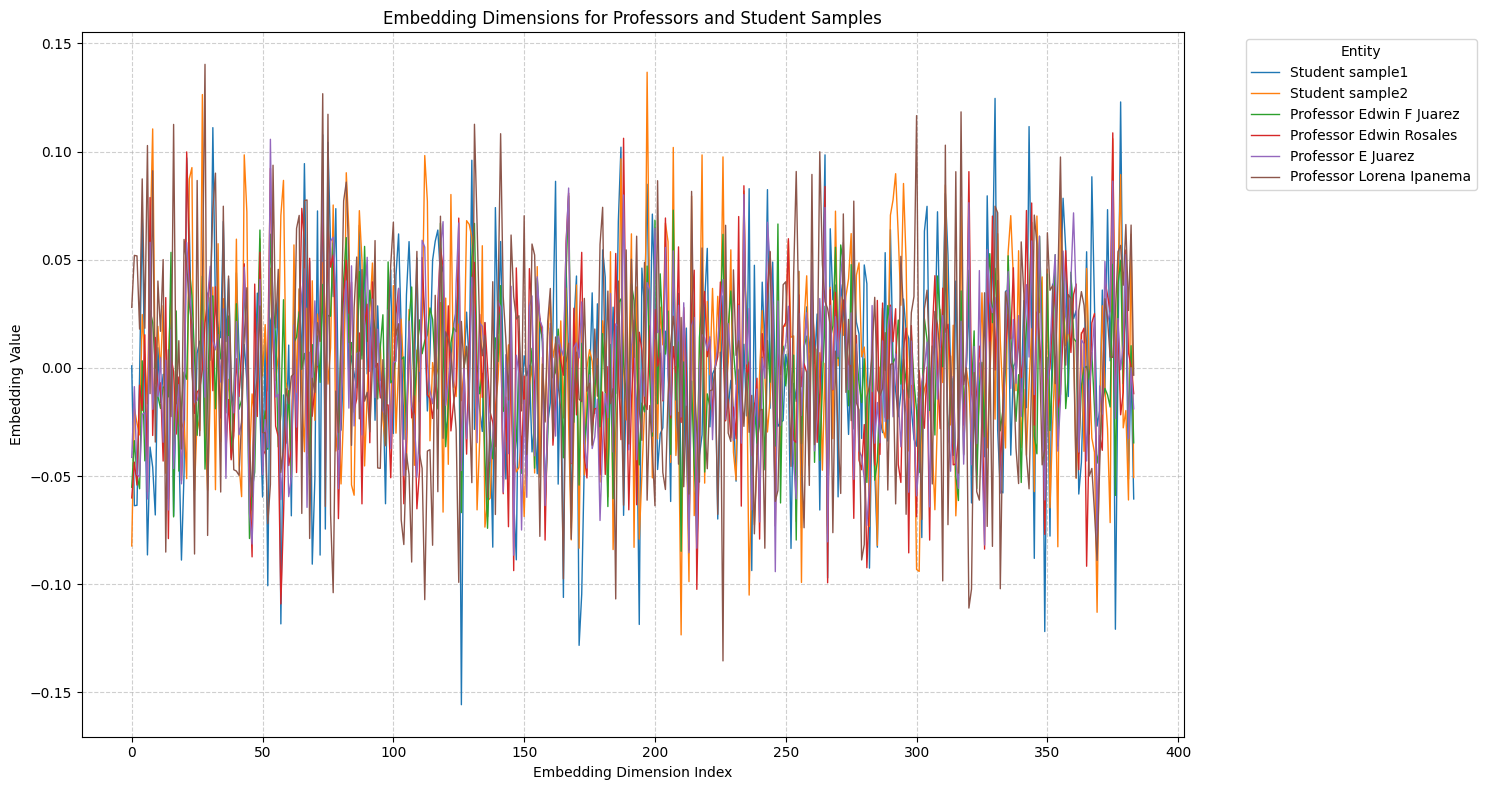

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

# Prepare data for embedding visualization
embedding_data = []

# Add student sample embeddings
if 'sample_embeddings' in locals() and 'sample_embeddings' in globals():
    for label, embedding_tensor in sample_embeddings.items():
        for i, value in enumerate(embedding_tensor.cpu().numpy()):
            embedding_data.append({'Entity': f'Student {label}', 'Dimension': i, 'Value': value})
else:
    print("Warning: 'sample_embeddings' not found. Please ensure the semantic similarity cell (PO3DGB70y-Mb) has been executed.")

# Add professor embeddings
if 'file_averaged_embeddings' in locals() and 'file_averaged_embeddings' in globals():
    for label, embedding_tensor in file_averaged_embeddings.items():
        for i, value in enumerate(embedding_tensor.cpu().numpy()):
            # Clean up filename for display
            display_label = label.replace('.txt', '').replace('_', ' ')
            embedding_data.append({'Entity': f'Professor {display_label}', 'Dimension': i, 'Value': value})
else:
    print("Warning: 'file_averaged_embeddings' not found. Please ensure the semantic similarity cell (PO3DGB70y-Mb) has been executed.")


embedding_df = pd.DataFrame(embedding_data)

if not embedding_df.empty:
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=embedding_df, x='Dimension', y='Value', hue='Entity', palette='tab10', linewidth=1)
    plt.title('Embedding Dimensions for Professors and Student Samples')
    plt.xlabel('Embedding Dimension Index')
    plt.ylabel('Embedding Value')
    plt.legend(title='Entity', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No embedding data available to plot.")

### Visualization 2: Embedding Visualization with PCA

To better visualize the high-dimensional embeddings (384 dimensions), we can use Principal Component Analysis (PCA) to reduce them to 2 dimensions. This allows us to plot the embeddings on a 2D scatter plot, where each point represents a professor or a student sample. Points that are close together in this 2D space are semantically more similar. This visualization helps in identifying clusters or relationships that are hard to discern in the raw 384-dimensional plot.

In [30]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np

# # Combine all embeddings for PCA
# # Ensure sample_embeddings and file_averaged_embeddings are available
# if 'sample_embeddings' not in locals() or 'file_averaged_embeddings' not in locals():
#     print("Error: Embeddings not found. Please ensure the semantic similarity cell (PO3DGB70y-Mb) has been executed.")
# else:
#     all_embeddings_list = []
#     labels = []

#     # Add student sample embeddings
#     for label, embedding_tensor in sample_embeddings.items():
#         all_embeddings_list.append(embedding_tensor.cpu().numpy())
#         labels.append(f'Student {label}')

#     # Add professor embeddings
#     for label, embedding_tensor in file_averaged_embeddings.items():
#         all_embeddings_list.append(embedding_tensor.cpu().numpy())
#         labels.append(f'Professor {label.replace('.txt', '').replace('_', ' ')}')

#     # Convert list of numpy arrays to a single numpy array
#     X = np.array(all_embeddings_list)

#     # Perform PCA
#     pca = PCA(n_components=2)
#     components = pca.fit_transform(X)

#     # Create a DataFrame for plotting
#     pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
#     pca_df['Entity'] = labels

#     # Plotting
#     plt.figure(figsize=(10, 8))
#     sns.scatterplot(x='PC1', y='PC2', hue='Entity', data=pca_df, s=100, alpha=0.8, palette='tab10')

#     # Add labels for each point
#     for i, row in pca_df.iterrows():
#         plt.text(row['PC1'] + 0.005, row['PC2'] + 0.005, row['Entity'], fontsize=9)

#     plt.title('2D PCA of Embeddings for Professors and Student Samples')
#     plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
#     plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.show()

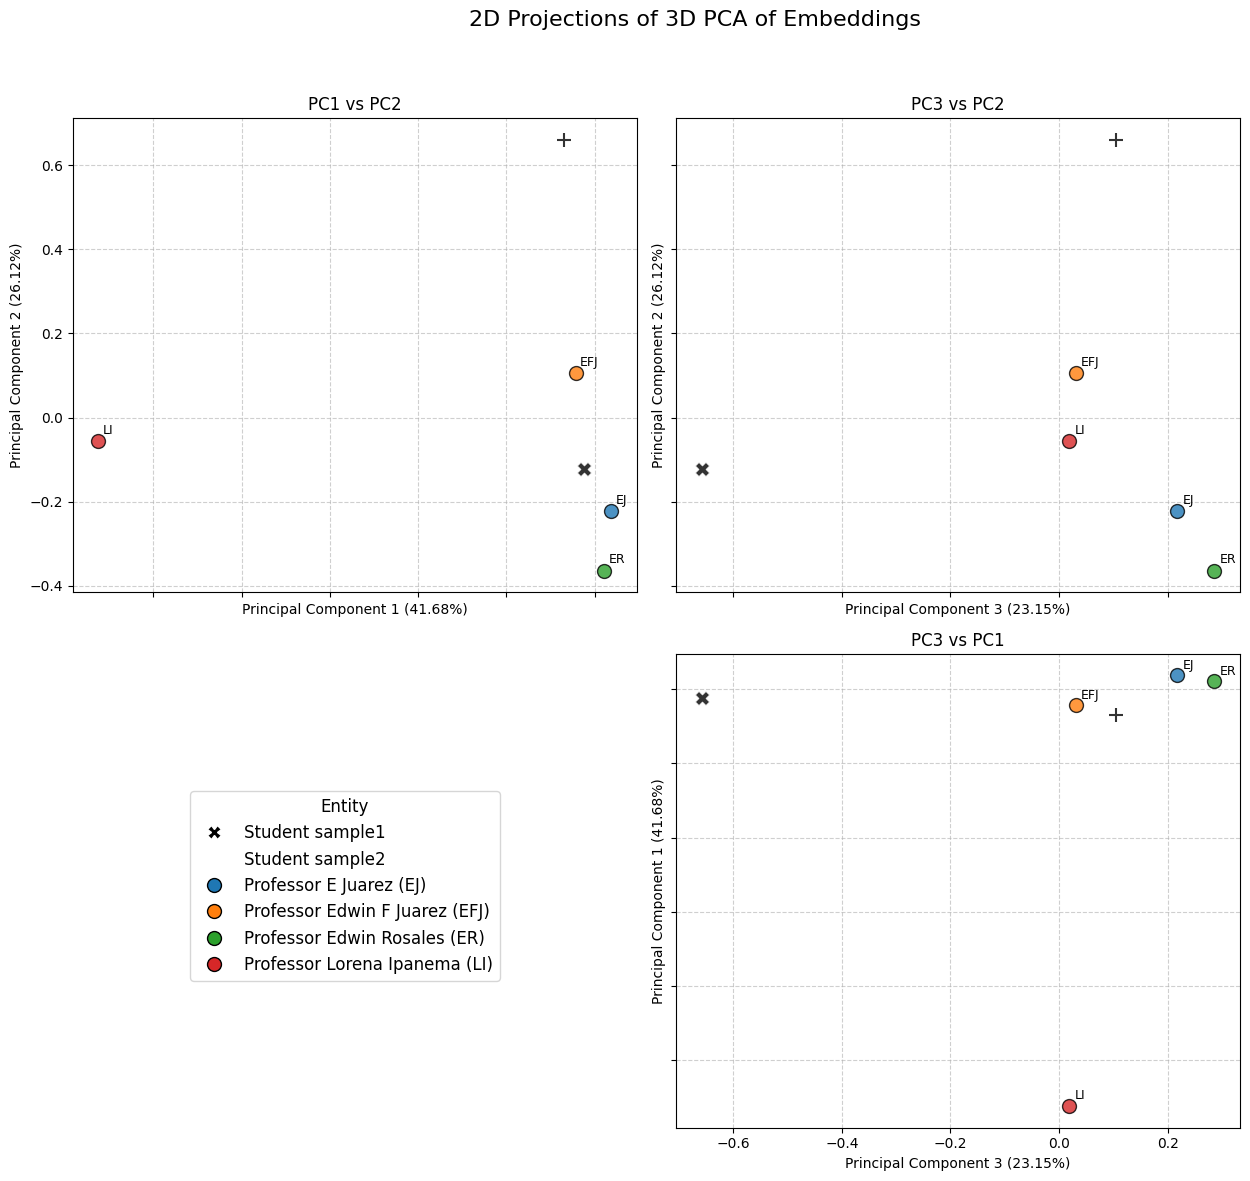

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Combine all embeddings for PCA
# Ensure sample_embeddings and file_averaged_embeddings are available
if 'sample_embeddings' not in locals() or 'file_averaged_embeddings' not in locals():
    print("Error: Embeddings not found. Please ensure the semantic similarity cell (PO3DGB70y-Mb) has been executed.")
else:
    all_embeddings_list = []
    labels = []
    entity_types = [] # To distinguish student vs professor easily

    # Add student sample embeddings
    for label, embedding_tensor in sample_embeddings.items():
        all_embeddings_list.append(embedding_tensor.cpu().numpy())
        labels.append(f'Student {label}')
        entity_types.append('Student')

    # Add professor embeddings
    for label, embedding_tensor in file_averaged_embeddings.items():
        all_embeddings_list.append(embedding_tensor.cpu().numpy())
        labels.append(f'Professor {label.replace('.txt', '').replace('_', ' ')}')
        entity_types.append('Professor')

    # Convert list of numpy arrays to a single numpy array
    X = np.array(all_embeddings_list)

    # Perform PCA with 3 components
    pca = PCA(n_components=3)
    components = pca.fit_transform(X)

    # Create a DataFrame for plotting
    pca_df_3d = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
    pca_df_3d['Entity'] = labels
    pca_df_3d['EntityType'] = entity_types # Add entity type for easier filtering

    # Plotting 2x2 grid of 2D projections
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex='col', sharey='row')
    fig.suptitle('2D Projections of 3D PCA of Embeddings', fontsize=16)

    # Define custom colors and markers
    student_color = 'black'
    student_marker_s1 = 'X'
    student_marker_s2 = '+'
    professor_marker = 'o'

    # Get unique professor names for distinct colors
    professor_names = sorted([e.replace('Professor ', '') for e in pca_df_3d['Entity'] if 'Professor' in e])
    professor_palette = sns.color_palette('tab10', n_colors=len(professor_names))
    professor_color_map = dict(zip(professor_names, professor_palette))


    # Function to plot on an axis
    def plot_pca_axis(ax, x_comp, y_comp, x_label_prefix, y_label_prefix, title_suffix):
        for i, row in pca_df_3d.iterrows():
            entity = row['Entity']
            entity_type = row['EntityType']
            x_val = row[x_comp]
            y_val = row[y_comp]

            if entity_type == 'Student':
                if 'sample1' in entity: # Assuming 'Student sample1' for first student
                    ax.scatter(x_val, y_val, color=student_color, marker=student_marker_s1, s=100, alpha=0.8, edgecolors='white', linewidth=0.5)
                elif 'sample2' in entity: # Assuming 'Student sample2' for second student
                    ax.scatter(x_val, y_val, color=student_color, marker=student_marker_s2, s=100, alpha=0.8, linewidth=1.5) # Increased linewidth for '+'
            else: # Professor
                prof_name = entity.replace('Professor ', '')
                ax.scatter(x_val, y_val, color=professor_color_map[prof_name], marker=professor_marker, s=100, alpha=0.8, edgecolors='black')
                # Add labels for professors
                initials = ''.join([word[0] for word in prof_name.split() if word])
                ax.text(x_val + 0.01, y_val + 0.01, initials, fontsize=9, color='black', ha='left', va='bottom')

        ax.set_xlabel(f'{x_label_prefix} ({pca.explained_variance_ratio_[int(x_comp.replace("PC", ""))-1]*100:.2f}%)')
        ax.set_ylabel(f'{y_label_prefix} ({pca.explained_variance_ratio_[int(y_comp.replace("PC", ""))-1]*100:.2f}%)')
        ax.set_title(title_suffix)
        ax.grid(True, linestyle='--', alpha=0.6)

    # --- Top-Left: XY Projection (PC1 vs PC2) ---
    plot_pca_axis(axes[0, 0], 'PC1', 'PC2', 'Principal Component 1', 'Principal Component 2', 'PC1 vs PC2')

    # --- Top-Right: YZ Projection (PC3 vs PC2) ---
    plot_pca_axis(axes[0, 1], 'PC3', 'PC2', 'Principal Component 3', 'Principal Component 2', 'PC3 vs PC2')

    # --- Bottom-Left: Empty Subplot ---
    ax10 = axes[1, 0]
    ax10.set_visible(False) # Hide the empty subplot

    # --- Bottom-Right: XZ Projection (PC3 vs PC1) ---
    plot_pca_axis(axes[1, 1], 'PC3', 'PC1', 'Principal Component 3', 'Principal Component 1', 'PC3 vs PC1')

    # Create custom legend entries
    from matplotlib.lines import Line2D
    legend_elements = []

    # Student legend entries
    legend_elements.append(Line2D([0], [0], marker=student_marker_s1, color='w', label='Student sample1',
                                  markerfacecolor=student_color, markersize=10, markeredgecolor='white', linewidth=0.5))
    legend_elements.append(Line2D([0], [0], marker=student_marker_s2, color='w', label='Student sample2',
                                  markerfacecolor=student_color, markersize=10, linewidth=1.5)) # Updated linewidth here as well

    # Professor legend entries
    for prof_name in professor_names:
        initials = ''.join([word[0] for word in prof_name.split() if word])
        legend_elements.append(Line2D([0], [0], marker=professor_marker, color='w', label=f'Professor {prof_name} ({initials})',
                                      markerfacecolor=professor_color_map[prof_name], markersize=10, markeredgecolor='black'))

    fig.legend(handles=legend_elements, title='Entity', bbox_to_anchor=(0.25, 0.25), loc='center', ncol=1, fontsize='large', title_fontsize='large')

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

**Note how similar Prof EFJ is to the student samples. Quantified above by the average similarity. If this is all we cared about we could stop here.**

### Visualization 2: Preference Vectors Heatmap

This heatmap visualizes the preference values for the student and the four professors across the four defined dimensions (Meeting Frequency, Structure, Communication Style, Management Style). Each row represents an individual's preference profile, and each column corresponds to a specific preference dimension. The color intensity indicates the preference value, making it easy to spot similarities and differences in communication and management styles.

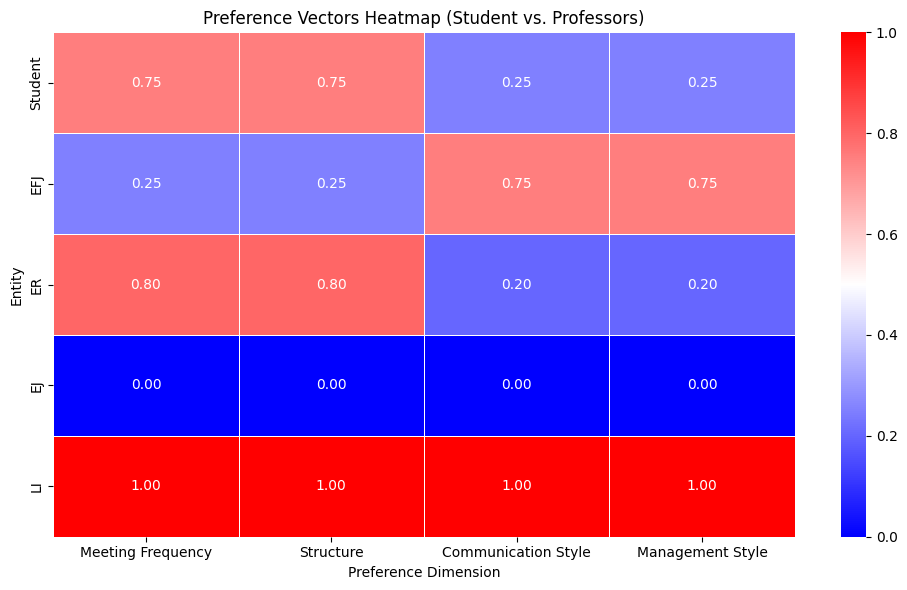

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for heatmap visualization

# Define the dimensions labels for better readability
dim_labels = ['Meeting Frequency', 'Structure', 'Communication Style', 'Management Style']

# Create a dictionary to hold all preference vectors
all_preferences = {
    'Student': student_preference, # student_preference is already a list
    'EFJ': EFJ_pref,
    'ER': ER_pref,
    'EJ': EJ_pref,
    'LI': LI_pref
}

# Create a DataFrame from the dictionary
preferences_df = pd.DataFrame.from_dict(all_preferences, orient='index', columns=dim_labels)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(preferences_df, annot=True, cmap='bwr', fmt=".2f", linewidths=.5) # Changed cmap to 'bwr'
plt.title('Preference Vectors Heatmap (Student vs. Professors)')
plt.xlabel('Preference Dimension')
plt.ylabel('Entity')
plt.tight_layout()
plt.show()

**Note how Professor ER shares a ton of Professional Preferences with the student. This is what makes it so in this demo the student is first recomended to prof ER and then to prof EFJ**